# Ad-Tech Campaign Performance & A/B Testing Analysis

## Project Overview

In this project I take on the role of a BI Analyst at an ad-tech
company, analyzing campaign performance for the first half of the
year (H1) and delivering recommendations to improve ad performance
over the following six months.

The analysis combines SQL and Python to evaluate campaign efficiency,
identify high-performing user segments, and statistically assess
whether a proposed new ad format should replace the current one.

## Dataset

The analysis draws on five related tables:

- **Campaigns** — campaign details, budget, and cost per install
- **CampaignViews** — individual ad view events
- **CampaignClicks** — individual click events
- **CampaignInstalls** — individual install events
- **Users** — user demographics (age group, gender, country)

## Approach

The project is structured in two sections:

**Section 1 — Campaign Performance Analysis**
Using SQL queries on a SQLite database, I evaluate individual
campaign performance, calculate efficiency KPIs such as cost per
install and Installs Per Mille (IPM), and identify which user
segments drive the strongest results.

**Section 2 — A/B Testing**
I assess the representativeness of the experiment's sampling, then
apply a two-proportion z-test and power analysis to determine
whether the new ad format delivers a statistically significant
improvement over the current format.

In [27]:
from IPython.core.payload import PayloadManager
#Importing necessary libraries
import pandas as pd
import sqlite3
import os
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving database.xlsx to database.xlsx


In [4]:
# load excel files into Python
df_campaigns = pd.read_excel('database.xlsx', sheet_name='Section1. Campaigns')
df_views = pd.read_excel('database.xlsx', sheet_name='Section1. CampaignViews')
df_clicks = pd.read_excel('database.xlsx', sheet_name='Section1. CampaignClicks')
df_installs = pd.read_excel('database.xlsx', sheet_name='Section1. CampaignInstalls')
df_users = pd.read_excel('database.xlsx', sheet_name='Section1. Users')

In [5]:
# Creating SQLite Tables
conn = sqlite3.connect('AdData.db')
df_campaigns.to_sql('Campaigns', conn, if_exists='replace')
df_views.to_sql('CampaignViews', conn, if_exists='replace')
df_clicks.to_sql('CampaignClicks', conn, if_exists='replace')
df_installs.to_sql('CampaignInstalls', conn, if_exists='replace')
df_users.to_sql('Users', conn, if_exists='replace')

1000

The data is now loaded and the SQLite tables are created successfully,
ready for querying.

**Note:** I used `if_exists='replace'` when creating the tables so
that re-running the notebook overwrites the existing tables rather
than raising an error. This makes the notebook safely repeatable.

## Part 2 — Analyzing Campaign Performance

As a first step, I evaluate individual campaign performance to
identify which campaigns performed well and which underperformed.

Using an SQL query, I retrieve the total views, clicks, installs,
total spend, total budget, and number of active days for each
campaign during 2024 H1, ranked from highest to lowest spend.

**Objectives:**
- Identify which campaigns outperformed and explain why
- Recommend budget adjustments based on the findings

In [6]:
conn = sqlite3.connect('AdData.db')
query = """
WITH
Views AS (
SELECT
	C.Campaign_id,
	COUNT(DISTINCT CV.View_id) AS ViewCount
FROM Campaigns C
	LEFT JOIN CampaignViews CV
		ON CV.Campaign_id = C.Campaign_id
WHERE CV."timestamp" BETWEEN '2024-01-01 00:00:00' AND '2024-06-30 23:59:59'
GROUP BY C.Campaign_id
),
Clicks AS (
SELECT
	C.Campaign_id,
	COUNT(DISTINCT CC.Click_id) AS ClickCount
FROM Campaigns C
	LEFT JOIN CampaignClicks CC
		ON CC.Campaign_id = C.Campaign_id
WHERE CC."timestamp" BETWEEN '2024-01-01 00:00:00' AND '2024-06-30 23:59:59'
GROUP BY C.Campaign_id
),
Installs AS (
SELECT
	C.Campaign_id,
	COUNT(DISTINCT CI.Install_id) AS InstallCount
FROM Campaigns C
	LEFT JOIN CampaignInstalls CI
		ON CI.Campaign_id = C.Campaign_id
WHERE CI."timestamp" BETWEEN '2024-01-01 00:00:00' AND '2024-06-30 23:59:59'
GROUP BY C.Campaign_id
)
SELECT
	C.Campaign_Name,
	C.TotalBudget,
	Views.ViewCount,
	Clicks.ClickCount,
	Installs.InstallCount,
	C.CostPerInstall * Installs.InstallCount AS TotalSpend,
	julianday(C.End_Date) - julianday(C.Start_Date) AS ActiveDays
FROM Campaigns C
	LEFT JOIN Views
		ON Views.Campaign_id = C.Campaign_id
	LEFT JOIN Clicks
		ON Clicks.Campaign_id = C.Campaign_id
	LEFT JOIN Installs
		ON Installs.Campaign_id = C.Campaign_id
WHERE C.Start_Date BETWEEN '2024-01-01' AND '2024-06-30'
	AND C.End_Date BETWEEN '2024-01-01' AND '2024-06-30'
ORDER BY TotalSpend DESC
"""

In [7]:
df_campaign_perf = pd.read_sql_query(query, conn)
df_campaign_perf

,Campaign_Name,TotalBudget,ViewCount,ClickCount,InstallCount,TotalSpend,ActiveDays
0,Campaign_2,25000,2474,954,199,9552,71.0
1,Campaign_6,25000,2499,1000,210,8610,26.0
2,Campaign_12,25000,2531,1068,197,8471,49.0
3,Campaign_13,20000,2450,939,198,8316,28.0
4,Campaign_3,20400,2416,1016,209,8151,14.0
5,Campaign_14,21000,2458,913,179,8055,97.0
6,Campaign_19,20000,2475,978,195,7995,20.0
7,Campaign_16,20000,2549,1022,206,7828,45.0
8,Campaign_5,50000,2476,969,201,7437,30.0
9,Campaign_7,26000,2633,1101,214,6848,10.0


To determine which campaigns outperformed, looking at total spend
or active days alone is not sufficient. Efficiency KPIs provide a
clearer picture of true performance:

- **CTR (Click-Through Rate)** = Clicks / Views
- **Install Rate** = Installs / Clicks
- **Install Efficiency** = Installs / Total Spend

These metrics reveal not just which campaigns spent the most, but
which delivered the best results per euro spent. For example,
campaigns achieving high installs at a low cost per install
represent the most efficient use of budget and may justify
increased investment, while campaigns spending heavily relative
to their install volume may warrant budget reduction or pausing.

In [8]:
df_campaign_perf['Cost_per_Install'] = np.where(
    df_campaign_perf['InstallCount'] > 0,
    df_campaign_perf['TotalSpend'] / df_campaign_perf['InstallCount'],
    np.nan
)
df_campaign_perf_sorted = df_campaign_perf.sort_values(by='Cost_per_Install', ascending=True)
df_campaign_perf_sorted[['Campaign_Name', 'Cost_per_Install']]

,Campaign_Name,Cost_per_Install
19,Campaign_8,11.0
17,Campaign_11,11.0
18,Campaign_4,12.0
15,Campaign_1,16.0
16,Campaign_9,16.0
14,Campaign_20,20.0
13,Campaign_17,23.0
12,Campaign_15,27.0
10,Campaign_18,29.0
9,Campaign_7,32.0


Based on cost per install, the campaigns fall into three clear
performance tiers, each with a corresponding action plan:

**Top performers** — Campaign_8, Campaign_11, and Campaign_4
achieved the lowest cost per install, making them the most
efficient use of budget. *Recommendation: increase investment.*

**Medium performers** — Campaign_1, Campaign_9, and Campaign_20
deliver acceptable efficiency. *Recommendation: maintain current
budget and continue monitoring.*

**Underperformers** — Campaign_2, Campaign_14, and Campaign_12
show high cost per install relative to results. *Recommendation:
reduce budget or pause.*

## Part 3 — Performance by User Segment

After reviewing overall campaign performance, I dig deeper to
identify which user segments are driving these results.

Using an SQL query, I calculate **IPM (Installs Per Mille)** —
installs per thousand views — for each campaign across every user
segment combination of age group, gender, and country.

IPM is a strong efficiency metric here because it normalizes
installs against view volume, allowing fair comparison between
segments of different sizes.

In [9]:
conn = sqlite3.connect('AdData.db')
query = """
WITH
Views AS (
    SELECT
        C.Campaign_id,
        U.AgeGroup,
        U.Gender,
        U.Country,
        COUNT(DISTINCT CV.View_id) AS ViewCount
    FROM Campaigns C
    LEFT JOIN CampaignViews CV
        ON CV.Campaign_id = C.Campaign_id
    LEFT JOIN Users U
        ON CV.User_id = U.User_id
    WHERE CV."timestamp" BETWEEN '2024-01-01' AND '2024-06-30'
    GROUP BY C.Campaign_id, U.AgeGroup, U.Gender, U.Country
),
Installs AS (
    SELECT
        C.Campaign_id,
        U.AgeGroup,
        U.Gender,
        U.Country,
        COUNT(DISTINCT CI.Install_id) AS InstallCount
    FROM Campaigns C
    LEFT JOIN CampaignInstalls CI
        ON CI.Campaign_id = C.Campaign_id
    LEFT JOIN Users U
        ON CI.User_id = U.User_id
    WHERE CI."timestamp" BETWEEN '2024-01-01' AND '2024-06-30'
    GROUP BY C.Campaign_id, U.AgeGroup, U.Gender, U.Country
),
UsersGroups AS (
    SELECT DISTINCT AgeGroup, Gender, Country FROM Users
)
SELECT
    UG.AgeGroup AS "Age-Group",
    UG.Gender,
    UG.Country,
    C.Campaign_Name AS Campaign_name,
    IFNULL(V.ViewCount, 0) AS ViewCount,
    IFNULL(I.InstallCount, 0) AS InstallCount,
    CASE
        WHEN IFNULL(V.ViewCount,0) > 0
        THEN 1000.0 * IFNULL(I.InstallCount,0)/V.ViewCount
        ELSE 0
    END AS IPM
FROM UsersGroups UG
CROSS JOIN Campaigns C
LEFT JOIN Views V
    ON V.Campaign_id = C.Campaign_id
    AND V.AgeGroup = UG.AgeGroup
    AND V.Gender = UG.Gender
    AND V.Country = UG.Country
LEFT JOIN Installs I
    ON I.Campaign_id = C.Campaign_id
    AND I.AgeGroup = UG.AgeGroup
    AND I.Gender = UG.Gender
    AND I.Country = UG.Country
WHERE C.Start_Date BETWEEN '2024-01-01' AND '2024-06-30'
  AND C.End_Date BETWEEN '2024-01-01' AND '2024-06-30'
ORDER BY UG.AgeGroup, UG.Gender, UG.Country, C.Campaign_Name
"""


In [10]:
df_ipm_perf = pd.read_sql_query(query, conn)
df_ipm_perf[['Age-Group','Gender','Country','Campaign_name','IPM']]

,Age-Group,Gender,Country,Campaign_name,IPM
0,18-24,Female,Austria,Campaign_1,18.867925
1,18-24,Female,Austria,Campaign_10,69.767442
2,18-24,Female,Austria,Campaign_11,22.727273
3,18-24,Female,Austria,Campaign_12,37.735849
4,18-24,Female,Austria,Campaign_13,37.037037
...,...,...,...,...,...
1195,65+,Male,USA,Campaign_5,32.258065
1196,65+,Male,USA,Campaign_6,37.037037
1197,65+,Male,USA,Campaign_7,73.170732
1198,65+,Male,USA,Campaign_8,54.054054


## Part 4 — Visualization

To make the segment-level IPM results easier to interpret, I create
several visualizations that highlight the differences in IPM across
user groups.

These charts reveal which age, gender, and country segments respond
most strongly to campaigns, providing a clear basis for targeting
recommendations.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

First, I visualize the average IPM across age, gender, and country
segments. A grouped bar chart is well suited here, as it allows
direct comparison of how different age and gender segments perform
within each country.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **p

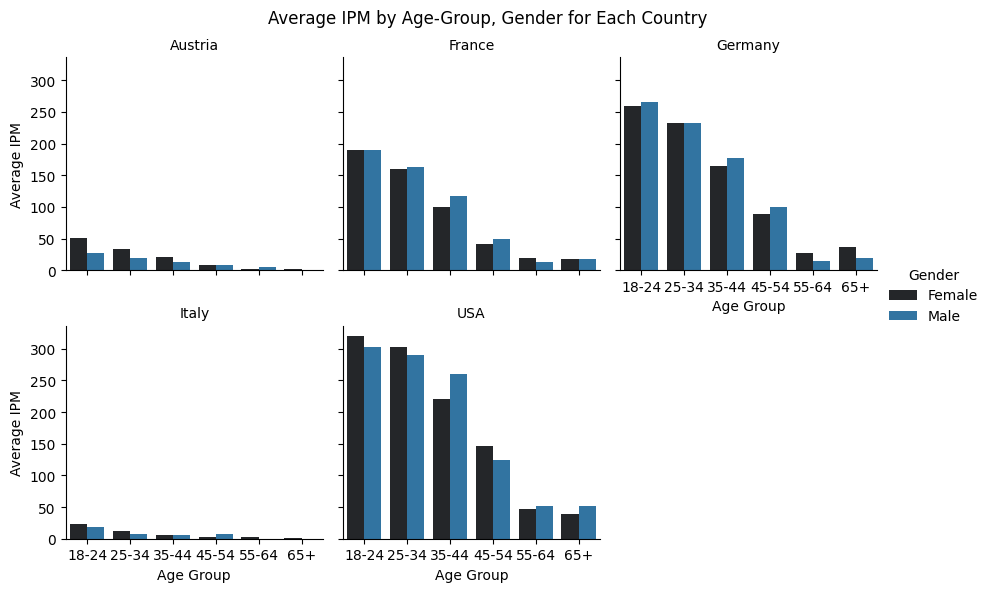

In [12]:
df_grouped = df_ipm_perf.groupby(['Age-Group', 'Gender', 'Country'])['IPM'].mean().reset_index()
graph = sns.FacetGrid(df_grouped, col="Country", col_wrap=3, height=3)
graph.map_dataframe(sns.barplot, x="Age-Group", y="IPM", hue="Gender")
graph.add_legend(title="Gender")
graph.set_axis_labels("Age Group", "Average IPM")
graph.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.9)
graph.fig.suptitle("Average IPM by Age-Group, Gender for Each Country")
plt.show()

These charts reveal several clear patterns:

- **USA and Germany** show the strongest performance, with average
  IPM around 250–300, concentrated in the **18–44 age range**.
- **Gender shows no significant effect** — male and female IPM are
  closely matched across all segments.
- **Italy and Austria** are the weakest markets, with average IPM
  below 50.

To examine which age and country combinations are most efficient,
I next use a heatmap, which makes high- and low-performing segments
immediately visible.

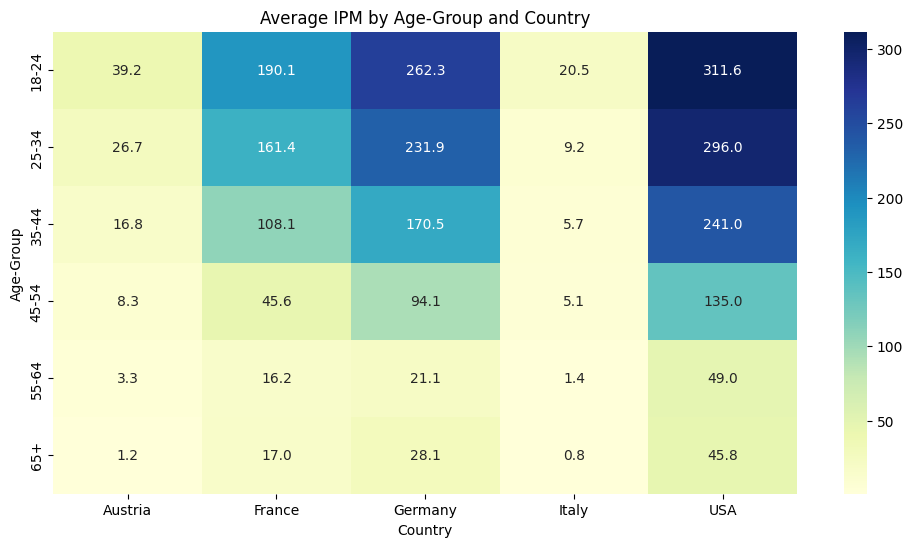

In [13]:
df_country = df_ipm_perf.groupby(['Age-Group', 'Country'])['IPM'].mean().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(df_country,annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average IPM by Age-Group and Country")
plt.ylabel("Age-Group")
plt.xlabel("Country")
plt.show()

The heatmap confirms the earlier findings — darker cells indicate
higher IPM. The strongest segment is clearly visible: users aged
**18–24 in the USA** generate the highest number of installs per
1,000 views, marking them as the single most efficient target
segment.

The other visualization which would be helpful is the comparision between different campaigns in different countries. To show that I will the bar plot:

/tmp/ipykernel_10316/2626318849.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_campaign_ipm, x='Campaign_name', y='IPM', palette="viridis")


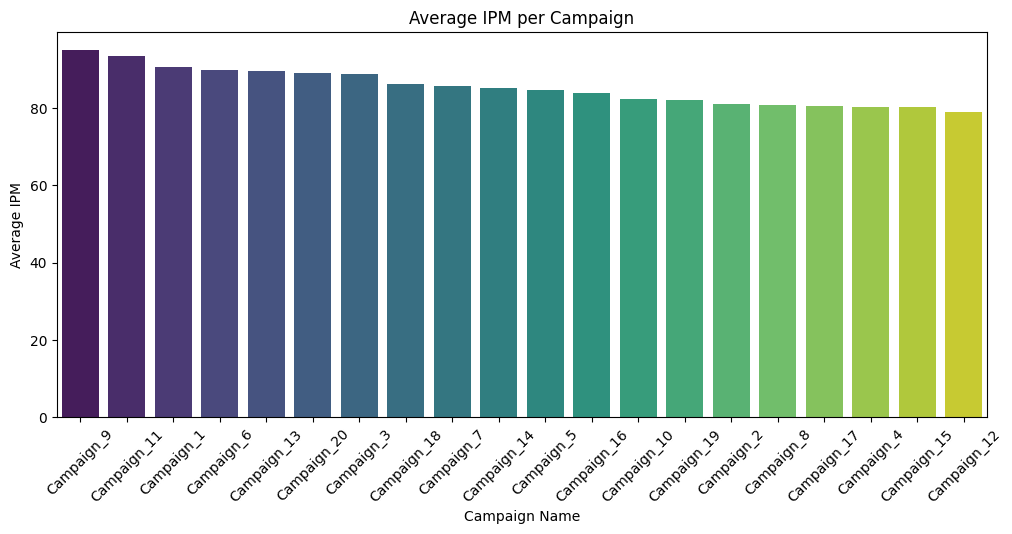

In [14]:
df_campaign_ipm = df_ipm_perf.groupby('Campaign_name')['IPM'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,5))
sns.barplot(data=df_campaign_ipm, x='Campaign_name', y='IPM', palette="viridis")
plt.title("Average IPM per Campaign")
plt.xticks(rotation=45)
plt.ylabel("Average IPM")
plt.xlabel("Campaign Name")
plt.show()

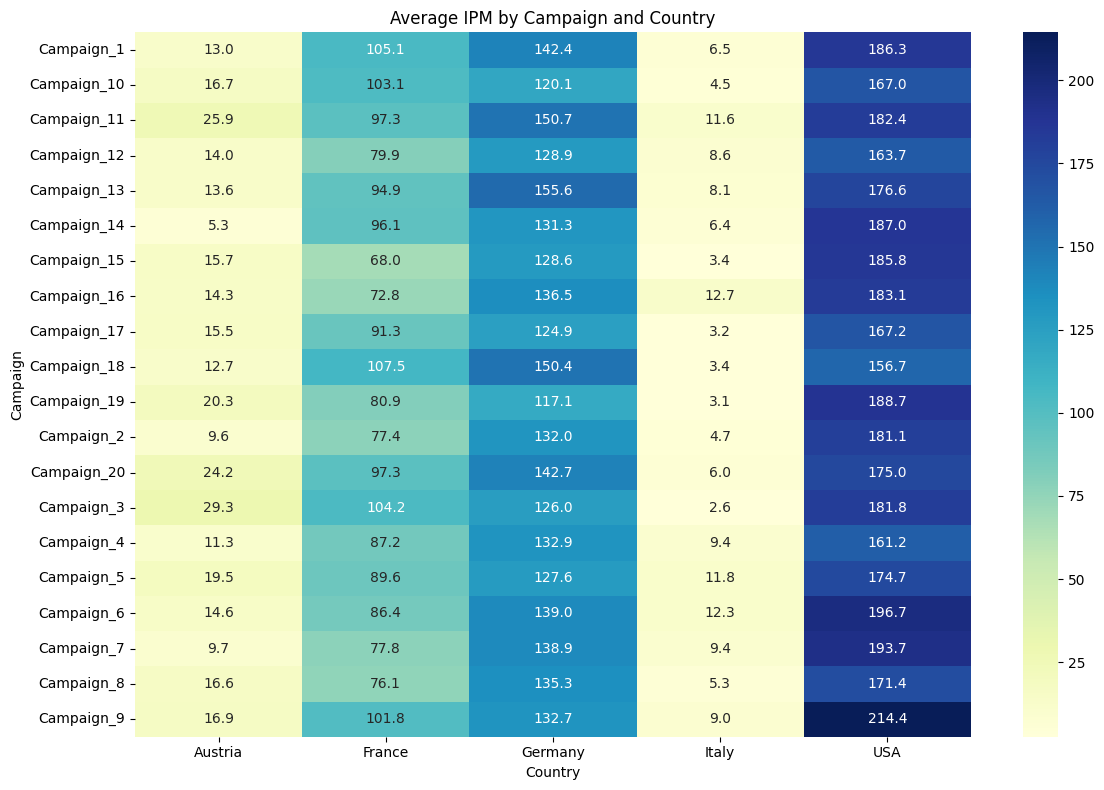

In [15]:
df_campaign_country = (
    df_ipm_perf
    .groupby(['Campaign_name', 'Country'])['IPM']
    .mean()
    .reset_index()
)
pivot_ipm = df_campaign_country.pivot(
    index='Campaign_name',
    columns='Country',
    values='IPM'
)
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_ipm,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Average IPM by Campaign and Country")
plt.xlabel("Country")
plt.ylabel("Campaign")
plt.tight_layout()
plt.show()

This heatmap shows which campaigns perform best in each country,
revealing that campaign effectiveness is highly market-dependent.

Campaign_9 is the strongest performer in the **USA and Germany**,
while in **France** Campaign_18 delivers the highest efficiency.
This variation highlights that no single campaign performs equally
well across all markets.

These insights enable targeted budget decisions — campaigns can be
scaled up in the markets where they excel and paused in markets
where they underperform, rather than applying a one-size-fits-all
budget strategy.

# Section 2 — A/B Testing

In this section I evaluate a proposed change to the ad format shown
to users. The goal is to compare user interaction with the new ad
format against the current format, and determine — using statistical
testing — whether the company should switch to the new format or
keep the existing one.

## Part 1 — Sampling Check

For this experiment, 20% of the total user base is assigned to the
**target group** (exposed to the new ad format), while the remaining
80% forms the **control group** (no change).

Before evaluating any results, I assess whether this sampling is
representative enough to measure the experiment's outcomes reliably —
checking for overlap between groups and comparing the distribution
of key user attributes across both groups.

**Answer:**

Although a 50/50 split is the most common choice in A/B testing and
is statistically more powerful than a 20/80 split, it is not always
optimal — each approach has trade-offs.

A 20/80 split is generally **safer**, because fewer users are exposed
to the new format. If the change negatively affects user experience
or revenue, this limits the cost of failure. The downside is **lower
statistical power**, meaning results may take longer to reach
significance and estimates can be less precise.

A 20/80 split is therefore acceptable, provided two conditions are met:

1. **Random assignment** — users must be randomly allocated to the
   control and target groups at the user level.
2. **Stable grouping** — users must remain in their assigned group
   for the full duration of the experiment, with no movement between
   groups, to avoid contamination effects.

Without proper randomization and stable grouping, the results would
be biased regardless of the split ratio.

To validate the experiment setup before analyzing results, I perform
a sampling and balance check:

- No overlap in user_id between the control and target groups
- Similar distributions of gender, age, and country across both groups
- Comparable ARPU distribution between the two groups

**Method:** For categorical variables (gender, country), I compare
distributions using stacked bar charts supported by chi-square tests.
For numerical variables (age, ARPU), I use box plots and summary
statistics, validated with t-tests or non-parametric alternatives
where appropriate.

If these checks confirm the groups are balanced, the 20/80 split can
produce reliable results. Otherwise, the outcomes may reflect
sampling bias.

In [16]:
file_path = '/content/database.xlsx'

control = pd.read_excel(
    file_path,
    sheet_name='Section2. Control Group'
)

target = pd.read_excel(
    file_path,
    sheet_name='Section2. Target Group'
)


In [17]:
control.shape, target.shape

((1000, 5), (199, 5))

In [18]:
control.head(), target.head()

(                            User_id  Gender  Age  Country  ARPU($)
 0  afe155a3a1f13b02af07ea74bf9c0e46    Male   64       UK    21.08
 1  f9949bd5ccd9fe32ac59f9a9a57b6294  Female   29  Germany    49.34
 2  e83a27de4022b1e224b6c44d38d56701  Female   33      USA    15.63
 3  440926db1afb10951124d788177b461e    Male   41  Germany    18.08
 4  9f2b80cd5b7da53efa497bde65915b95    Male   36   Canada    17.37,
                             User_id  Gender  Age Country  ARPU($)
 0  2cf9ca172771d701074a411fcb65170a  Female   65      UK    20.28
 1  1d040f4e8cecb2a747efe8d8c6d2caa4  Female   56   China    48.57
 2  4519bfb017eb317bf9c851851464373c  Female   45   China    20.13
 3  ddcabc19d9beb46d4e9684633c88b596    Male   47  Canada    52.79
 4  7dac8fe1a360de6b898034f13ec94210  Female   54  Canada    75.33)

In [19]:
overlap_users = set(control['User_id']).intersection(set(target['User_id']))
len(overlap_users)

0

As we can see there is no overlap between the users in control and target groups.

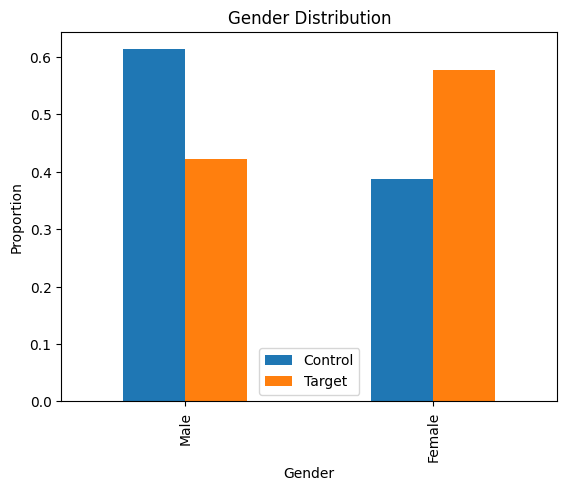

In [20]:
gender_dist = pd.concat([
    control['Gender'].value_counts(normalize=True).rename('Control'),
    target['Gender'].value_counts(normalize=True).rename('Target')
], axis=1)

gender_dist.plot(kind='bar', stacked=False)
plt.title('Gender Distribution')
plt.ylabel('Proportion')
plt.show()


In [21]:
from scipy.stats import chi2_contingency

gender_table = pd.crosstab(
    pd.concat([control['Gender'], target['Gender']]),
    ['Control'] * len(control) + ['Target'] * len(target)
)

chi2, p, _, _ = chi2_contingency(gender_table)
p


np.float64(9.287931259269297e-07)

The control and target groups are not well balanced in terms of gender distribution, which may bias the A/B test results.

There is a significant difference in the gender distribution between
the two groups, which could potentially bias the results. However,
as established in Section 1, gender showed no meaningful effect on
the critical performance KPIs — so this imbalance is unlikely to
materially distort the experiment's outcome.

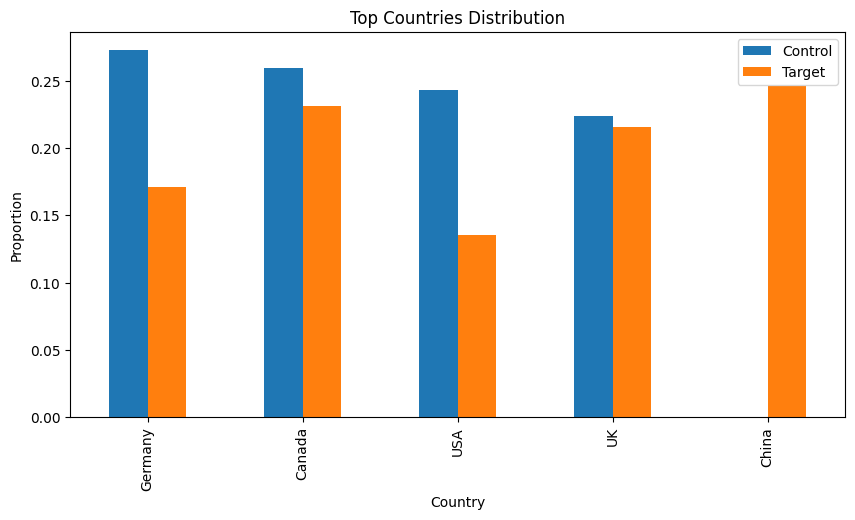

In [22]:
all_countries = pd.concat([control['Country'], target['Country']])
top_countries_list = all_countries.value_counts().index

country_dist = pd.concat([
    control['Country'].value_counts(normalize=True).rename('Control'),
    target['Country'].value_counts(normalize=True).rename('Target')
], axis=1).fillna(0)

country_dist.plot(kind='bar', figsize=(10,5))
plt.title('Top Countries Distribution')
plt.ylabel('Proportion')
plt.show()


Target and Control groups are also not well balanced in terms of country. For instance we do not have any data for china in our control data and it may bais our AB test results.

/tmp/ipykernel_10316/3243790859.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([control['Age'].dropna(), target['Age'].dropna()],


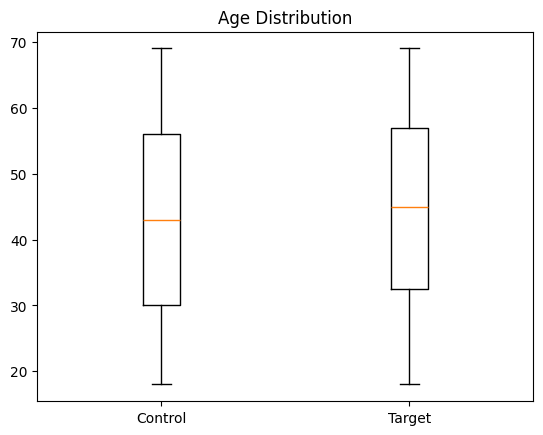

In [23]:
plt.boxplot([control['Age'].dropna(), target['Age'].dropna()],
            labels=['Control', 'Target'])
plt.title('Age Distribution')
plt.show()


based on the box plot in Age distribution we can conclude that our age groups are balance in our two datasets and so there is no concern regarding this term on our A/B test.

/tmp/ipykernel_10316/3101582203.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([control['ARPU($)'].dropna(), target['ARPU($)'].dropna()],


Text(0.5, 1.0, 'ARPU Distribution')

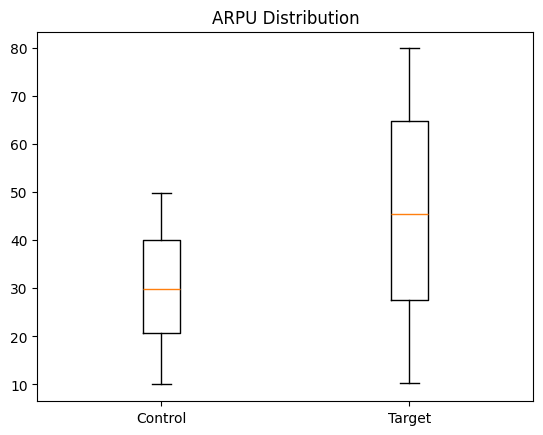

In [24]:
plt.boxplot([control['ARPU($)'].dropna(), target['ARPU($)'].dropna()],
            labels=['Control', 'Target'])
plt.title('ARPU Distribution')



ARPU in the target group is significantly higher than in the control
group, which could introduce bias into the A/B test results.

**In summary:** the 20/80 split is acceptable from a risk perspective,
but the sampling is not fully representative. Significant imbalances
in ARPU, country, and gender distributions suggest that the observed
effects may be confounded. As a result, the experiment should be
interpreted with caution, and future tests should be improved through
stronger randomization and better balanced groups.

# Part 2 — Evaluating A/B Test Results

Assuming the sample is representative, the A/B test was run for a
two-week period. The results are summarized below:

| Group | Ad Format | Impressions (Views) | Clicks | CTR |
|-------|-----------|---------------------|--------|-----|
| Control | Old format | 4,000 | 500 | 12.5% |
| Target | New format | 1,000 | 140 | 14.0% |

Based on these results, I evaluate whether the company should switch
to the new ad format — testing not just the observed difference, but
whether that difference is statistically significant given the sample
sizes involved.
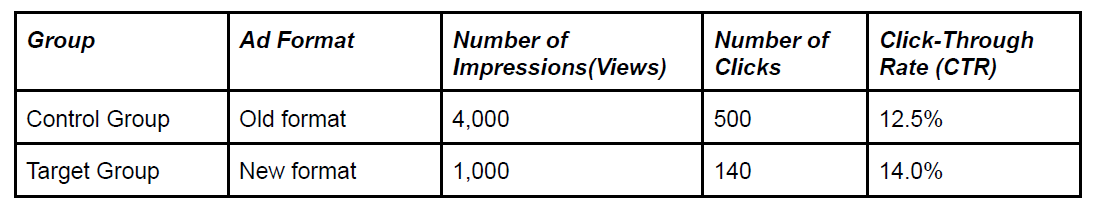
Based on the results above, do you recommend switching to the new format ?

**Initial Observation:**

At first glance, the target group's CTR is higher than the control
group's — a difference of 1.5 percentage points, which translates
to an approximate 12% relative lift:

(14.0% − 12.5%) / 12.5% × 100 = 12%

While this is promising and suggests the new format may perform
better, two factors caution against an immediate conclusion: the
difference may not be statistically significant, and the target
group has a notably smaller sample size (1,000 vs 4,000 impressions).

To reach a definitive conclusion, I apply a two-proportion z-test
to determine whether the difference is statistically significant,
followed by a power analysis to assess whether the sample size was
sufficient to detect an effect of this magnitude.

## Statistical Significance Test

To determine whether the 1.5pp CTR difference is statistically
significant or due to random chance, I ran a two-proportion z-test.

In [25]:
from statsmodels.stats.proportion import proportions_ztest

# Clicks (successes) and views (trials) for each group
clicks = np.array([500, 140])      # control, target
views  = np.array([4000, 1000])    # control, target

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count=clicks, nobs=views)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: statistically significant — the new format performs differently")
else:
    print("Result: NOT statistically significant — cannot conclude the new format is better")

Z-statistic: -1.2699
P-value: 0.2041
Result: NOT statistically significant — cannot conclude the new format is better


The two-proportion z-test returned a z-statistic of −1.27 and a
p-value of 0.204. Since the p-value is well above the standard
significance threshold of 0.05, the difference in click-through
rate between the two formats is **not statistically significant**.

Although the new format shows a higher CTR (14.0% vs 12.5%), this
1.5 percentage point lift cannot be distinguished from random
chance. A p-value of 0.20 means there is roughly a 20% probability
of observing a difference this large even if the two formats
performed identically.

**Recommendation:** I do not recommend switching to the new format
based on this data. The result is promising but inconclusive.

The primary limitation is the small size of the target group — only
1,000 impressions compared to 4,000 in the control group. This
limits the statistical power of the test, making it difficult to
detect a true effect of this size. Before making a decision, the
company should either extend the test duration or increase the
target group sample size, then re-evaluate significance.

## Power Analysis — Required Sample Size

To quantify how many users would be needed to reliably detect a
1.5pp lift, I ran a power analysis at 80% power and 5% significance.

In [26]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Effect size between the two CTRs
effect = proportion_effectsize(0.140, 0.125)

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=effect,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

print(f"Effect size: {effect:.4f}")
print(f"Required sample size per group: {required_n:,.0f}")

Effect size: 0.0443
Required sample size per group: 8,013


**Interpretation:**

The power analysis shows that to reliably detect a 1.5 percentage
point lift (from 12.5% to 14.0%) at 80% power and 5% significance,
approximately **8,013 impressions per group** would be required.

The actual test used only 1,000 impressions in the target group —
roughly **8 times fewer** than needed. This confirms that the
experiment was underpowered and explains why a seemingly positive
result failed to reach statistical significance.

**Final recommendation:** The new ad format shows early promise,
but the current test cannot support a confident business decision.
Before rolling out the new format, the company should run the
experiment until each group reaches at least ~8,000 impressions.
At that scale, if the 1.5pp lift persists, it would be statistically
significant and the switch could be justified with confidence.

In [28]:
import os
os.makedirs("charts", exist_ok=True)